## Research Question
Do consumers shift discretionary spending from big-ticket goods toward affordable indulgences during periods of economic distress?

## Secondary Question
Has this spending pattern changed in the modern social media era?

## ML Question
Can economic indicators predict shifts in spending between affordable indulgences and big-ticket discretionary goods?


In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
consumption = pd.read_csv("/Users/rundalsayed/Lipstick Effect/raw data/statcan_household_consumption.csv",skiprows=8)
consumption_clean = consumption.iloc[4:23].copy() # cleaning data from citations and metadata
consumption_clean.columns = consumption.iloc[2] # replaced column to quarters
consumption_clean = consumption_clean.rename(columns={"Estimates": "Category"})
consumption_clean.columns.name = None # removes column index

categories_to_remove = ["Clothing materials, other articles of clothing and clothing accessories",
    "Major tools and equipment",
    "Recreational and sporting services"]

consumption_clean = consumption_clean[
    ~consumption_clean["Category"].isin(categories_to_remove)
] # makes a df without the categories to remove

consumption_long = consumption_clean.melt( # converts data from wide to long
    id_vars="Category",
    var_name="Quarter",
    value_name="Spending"
)

consumption_long["Spending"] = consumption_long["Spending"].str.replace(",","",regex=False).astype(float) # converts spending from string to float
# consumption_long.info() # checks columns' data types

consumption_long["Quarter"] = ( # convert quarters from strings to real quarterly periods
    consumption_long["Quarter"]
    .str.replace(r"Q([1-4]) (\d{4})", r"\2Q\1", regex=True) # rearranges Stat Can's quarter format to one that pandas understands
)
consumption_long["Quarter"] = pd.PeriodIndex(consumption_long["Quarter"],freq="Q") # converts quarters to time value
consumption_long["Quarter"].dtype

consumption_long.isna().sum() # checks for missing values

consumption_long.duplicated(
    subset=["Category", "Quarter"] # checks for duplicate values
).sum()

consumption_long["Category"].unique()

<ArrowStringArray>
[                                                    'Garments',
                                                     'Footwear',
                                    'Furniture and furnishings',
                                   'Major household appliances',
                                           'New passenger cars',
                  'New trucks, vans and sport utility vehicles',
                                          'Used motor vehicles',
                        'Major durables for outdoor recreation',
 'Musical instruments and major durables for indoor recreation',
                                      'Games, toys and hobbies',
                                                      'Cinemas',
                                   'Personal grooming services',
                      'Electrical appliances for personal care',
    'Other appliances, articles and products for personal care',
                                'Jewellery, clocks and watches',
      

In [3]:
category_groups = { # creates a dictionary of categories and their groups
    "Games, toys and hobbies": "Affordable indulgence",
    "Cinemas": "Affordable indulgence",
    "Personal grooming services": "Affordable indulgence",
    "Electrical appliances for personal care": "Affordable indulgence",
    "Other appliances, articles and products for personal care": "Affordable indulgence",

    "Furniture and furnishings": "Big-ticket",
    "Major household appliances": "Big-ticket",
    "New passenger cars": "Big-ticket",
    "New trucks, vans and sport utility vehicles": "Big-ticket",
    "Used motor vehicles": "Big-ticket",
    "Major durables for outdoor recreation": "Big-ticket",
    "Musical instruments and major durables for indoor recreation": "Big-ticket",

    "Garments": "Fashion comparison",
    "Footwear": "Fashion comparison",

    "Jewellery, clocks and watches": "Luxury/ambiguous",
    "Other personal effects": "Luxury/ambiguous"
}

consumption_long["Group"] = consumption_long["Category"].map(category_groups) # creates a new "Group" column by looking up each Category in the category_groups dictionary
consumption_long["Group"].isna().sum()

np.int64(0)

In [4]:
unemployment = pd.read_csv("/Users/rundalsayed/Lipstick Effect/raw data/unemployment_rate.csv",skiprows=8)
unemployment_clean = unemployment.iloc[[5]].copy() # copies the row with the observations
unemployment_clean.columns = unemployment.iloc[3] # copies the columns with the actual valid columns
unemployment_long = unemployment_clean.melt(
    id_vars = ["Labour force characteristics", "Data type"], # which columns should NOT get melted
    var_name = "Month", # the column we want to rename
    value_name = "Unemployment Rate"
    
)
unemployment_long = unemployment_long[["Month","Unemployment Rate"]] # converts Month from string to float
unemployment_long["Month"] = pd.to_datetime(
    unemployment_long["Month"],
    format="%B %Y"
)

unemployment_long["Unemployment Rate"] = (
    unemployment_long["Unemployment Rate"].astype(float)
)

unemployment_long["Quarter"] = unemployment_long["Month"].dt.to_period("Q") # creates quarters from the months
unemployment_quarterly = ( # calculates the average unemployment rate by quarter
    unemployment_long
    .groupby("Quarter")["Unemployment Rate"]
    .mean()
    .reset_index()
)

unemployment_quarterly.head()

,Quarter,Unemployment Rate
0,1990Q1,7.633333
1,1990Q2,7.666667
2,1990Q3,8.166667
3,1990Q4,9.133333
4,1991Q1,10.166667


In [5]:
cpi = pd.read_csv(
    "/Users/rundalsayed/Lipstick Effect/raw data/cpi.csv",
    skiprows=8
)

cpi_clean = cpi.iloc[[2]].copy()
cpi_clean.columns = cpi.iloc[0]
cpi_clean.head()

cpi_long = cpi_clean.melt(
    id_vars="Products and product groups 7", # what columns need to stay (unmelted)
    var_name="Month", # what do the old column names represent
    value_name="CPI" # what do the numbers next to month represent
)
cpi_long = cpi_long[["Month","CPI"]]

cpi_long["Month"] = pd.to_datetime( # convert month from string to date
    cpi_long["Month"],
    format="%B %Y"
)

cpi_long["CPI"] = cpi_long["CPI"].astype(float) # convert CPI from string to float

cpi_long["Quarter"] = cpi_long["Month"].dt.to_period("Q") # create quarters from months
cpi_quarterly = ( # calculates CPI for each quarter by averaging months
    cpi_long
    .groupby("Quarter")["CPI"]
    .mean()
    .reset_index()
)

# Calculate inflation
# How much higher is the CPI this quarter compared with the same quarter one year earlier?

cpi_quarterly["Inflation"] = (
    cpi_quarterly["CPI"].pct_change(periods=4) * 100
)

cpi_quarterly.head(8)

,Quarter,CPI,Inflation
0,1992Q1,83.300000,NaN
1,1992Q2,83.900000,NaN
2,1992Q3,84.200000,NaN
3,1992Q4,84.533333,NaN
4,1993Q1,85.100000,2.160864
5,1993Q2,85.366667,1.748113
6,1993Q3,85.666667,1.741884
7,1993Q4,86.066667,1.813880


In [6]:
gdp = pd.read_csv("/Users/rundalsayed/Lipstick Effect/raw data/gdp.csv", skiprows=8)
gdp_clean = gdp.iloc[[4]].copy()
gdp_clean.columns = gdp.iloc[2]

gdp_long = gdp_clean.melt(
    id_vars="Estimates",
    var_name="Quarter",
    value_name="GDP"
)

gdp_long = gdp_long[["Quarter","GDP"]]


gdp_long["GDP"] = gdp_long["GDP"].str.replace(",","",regex=False).astype(float) # removes commas from GDP to be able to convert it to a float

gdp_long["Quarter"] = ( # reorders quarter format from Q11992 to 1992Q1
    gdp_long["Quarter"]
    .str.replace(
        r"Q([1-4]) (\d{4})",
        r"\2Q\1",
        regex=True
    )
)

gdp_long["Quarter"] = pd.PeriodIndex(
    gdp_long["Quarter"],
    freq="Q"
)

gdp_quarterly = gdp_long[["Quarter", "GDP"]].copy()

gdp_quarterly["GDP Growth"] = (
    gdp_quarterly["GDP"].pct_change(periods=4) * 100 # calculates GDP growth over each year

)
gdp_quarterly.head(8)

,Quarter,GDP,GDP Growth
0,1992Q1,1139828.0,NaN
1,1992Q2,1141127.0,NaN
2,1992Q3,1147308.0,NaN
3,1992Q4,1153845.0,NaN
4,1993Q1,1161171.0,1.872475
5,1993Q2,1171748.0,2.683400
6,1993Q3,1182954.0,3.106925
7,1993Q4,1188014.0,2.961316


In [7]:
import requests

url = "https://www.bankofcanada.ca/valet/observations/V122530/json?start_date=1992-01-01"

response = requests.get(url) # retrieving the bank rates through the Bank of Canada's Valet API
response.status_code # checks whether our request worked. 200 is the standard HTTP code meaning OK

data = response.json()
type(data)
data.keys() # gets keys from the data dictionary
len(data["observations"])
data["observations"][:3] # returns first 3 observations
# type(data["observations"])

interest_rate = pd.DataFrame(data["observations"])

interest_rate.head() # returns a dict of bank rates so we need to get rid of 'v' and extract the value from it

interest_rate["Bank Rate"] = interest_rate["V122530"].apply(lambda x: x["v"]) # takes an object x, and returns the value belonging to its "v" key in it

interest_rate["Bank Rate"] = interest_rate["Bank Rate"].astype(float)
interest_rate = interest_rate.drop(columns="V122530")

interest_rate["d"] = pd.to_datetime(interest_rate["d"])
interest_rate["Quarter"] = interest_rate["d"].dt.to_period("Q")
interest_rate_quarterly = (
    interest_rate
    .groupby("Quarter")["Bank Rate"]
    .mean()
    .reset_index()
)


In [8]:
economic_data = pd.merge(unemployment_quarterly, cpi_quarterly, on="Quarter", how="inner")
economic_data = pd.merge(economic_data, gdp_quarterly, on="Quarter", how="inner")
economic_data = pd.merge(economic_data, interest_rate_quarterly, on="Quarter", how="inner") # merges all the economic indicators 
economic_data.head()
# economic_data.isna().sum() # calculates the sum of null values from each column
economic_data = economic_data.dropna().reset_index(drop=True) # removes null values

economic_data.shape

(134, 7)

In [9]:
full_data = pd.merge( # merges the consumption spending data with economic indicators data
    consumption_long,
    economic_data,
    on="Quarter",
    how="inner"
)

full_data.head()
full_data.shape

full_data["Group"].value_counts() # counts how many rows belong to each spending group


Group
Big-ticket               938
Affordable indulgence    670
Fashion comparison       268
Luxury/ambiguous         268
Name: count, dtype: int64

In [10]:
full_data = full_data.sort_values(["Category","Quarter"]) # orders by Category first then Quarter
full_data["Category Spending Growth"] = full_data.groupby("Category")["Spending"].pct_change(periods=4)*100

full_data[["Category Spending Growth", "Category","Quarter","Spending"]].head()

analysis = full_data[
    full_data["Group"].isin(
        ["Affordable indulgence", "Big-ticket"] # removes fashion comparison and luxury/ambiguous groups
    )
].copy()

group_growth = ( # combines the individual category spending growths into one group growth rate for each group and quarter
    analysis
    .groupby(["Quarter", "Group"])["Category Spending Growth"]
    .median() # used median because it's more robust to outliers than the mean
    .reset_index()
)

group_growth_wide = group_growth.pivot(
    index="Quarter",
    columns="Group",
    values="Category Spending Growth"
).reset_index()

group_growth_wide["Relative Shift"] = (
    group_growth_wide["Affordable indulgence"]
    - group_growth_wide["Big-ticket"]
)

# A positive Relative Shift means affordable indulgences performed better than big-ticket spending that quarter.

# A negative Relative Shift means big-ticket spending performed better.

# A value around 0 means the two groups grew at roughly the same rate.

group_growth_wide.describe()

Group,Affordable indulgence,Big-ticket,Relative Shift
count,130.000000,130.000000,130.000000
mean,3.554016,3.161643,0.392373
std,3.122635,5.688628,5.209158
min,-3.434226,-18.770227,-20.640230
25%,1.516877,1.045999,-2.024600
50%,3.372889,3.612374,-0.440824
75%,5.000000,6.067551,2.034196
max,18.933926,39.574156,23.126577


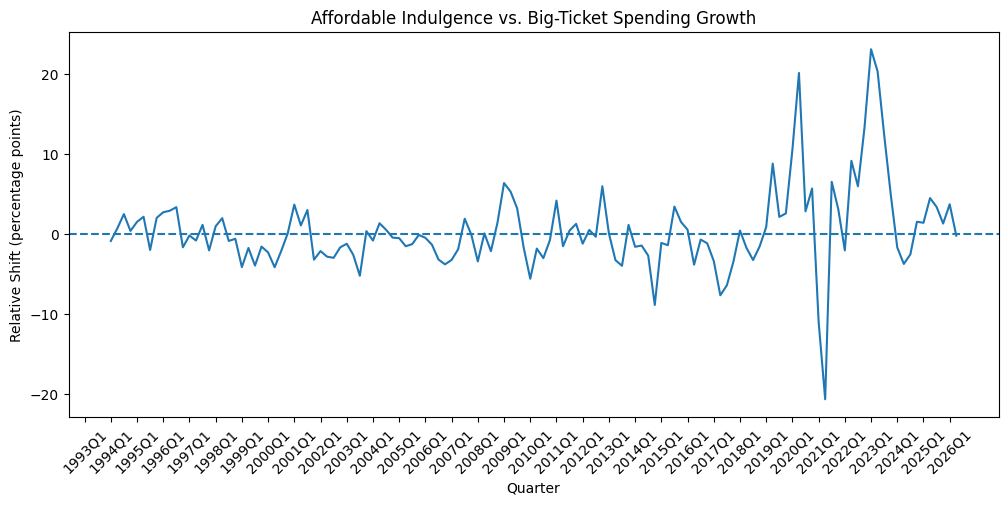

In [11]:
plt.figure(figsize=(12, 5))

plt.plot(
    group_growth_wide["Quarter"].astype(str),
    group_growth_wide["Relative Shift"]
)

plt.axhline(0, linestyle="--")

plt.title("Affordable Indulgence vs. Big-Ticket Spending Growth")
plt.xlabel("Quarter")
plt.ylabel("Relative Shift (percentage points)")
# plots relative shift over every yearly quarter 

plt.xticks(
    ticks=range(0, len(group_growth_wide), 4),
    labels=group_growth_wide["Quarter"].astype(str).iloc[::4],
    rotation=45
)

plt.show()
# relative shift above 0 means spending on affordable indulgences grew higher than spending on big-ticket goods

The graph illustrates that around 2020-2023, Affordable Indulgence growth became enormously larger than Big-ticket growth. This may be due to COVID, as it created extreme base effects, especially for categories such as cinemas and personal grooming services, which collapsed during restrictions and then rebounded from unusually low levels.

In [12]:
full_data.nlargest( # checks which 15 categories had the highest Spending Growth
    15,
    "Category Spending Growth"
)[
    ["Quarter", "Category", "Group", "Category Spending Growth"]
]

,Quarter,Category,Group,Category Spending Growth
1866,2022Q1,Cinemas,Affordable indulgence,2820.000000
1850,2021Q4,Cinemas,Affordable indulgence,1977.777778
1882,2022Q2,Cinemas,Affordable indulgence,739.130435
1834,2021Q3,Cinemas,Affordable indulgence,604.761905
1818,2021Q2,Cinemas,Affordable indulgence,475.000000
1822,2021Q2,"Jewellery, clocks and watches",Luxury/ambiguous,64.541213
1812,2021Q2,New passenger cars,Big-ticket,55.555556
1883,2022Q2,Personal grooming services,Affordable indulgence,54.920853
1819,2021Q2,Personal grooming services,Affordable indulgence,54.739084
1813,2021Q2,"New trucks, vans and sport utility vehicles",Big-ticket,45.180643


In [13]:
analysis_data = pd.merge( # merges group spending growth data with economic indicators data
    group_growth_wide,
    economic_data,
    on="Quarter", # match rows where Quarter is the same in both data frames
    how="inner" # only keep quarters that exist in BOTH data frames
)
# we can test whether economic distress systematically lines up with positive Relative Shift

analysis_data = analysis_data.dropna().reset_index(drop=True)
analysis_data.head() 

,Quarter,Affordable indulgence,Big-ticket,Relative Shift,Unemployment Rate,CPI,Inflation,GDP,GDP Growth,Bank Rate
0,1994Q1,1.612903,2.460568,-0.847665,11.033333,85.533333,0.509205,1205531.0,3.820281,4.540000
1,1994Q2,3.346568,2.608696,0.737873,10.633333,85.266667,-0.117142,1223130.0,4.385073,6.433333
2,1994Q3,6.557377,4.045512,2.511865,10.133333,85.766667,0.116732,1238811.0,4.721824,5.726667
3,1994Q4,7.977208,7.569539,0.407669,9.766667,86.100000,0.038730,1247810.0,5.033274,6.363333
4,1995Q1,6.159015,4.618227,1.540788,9.633333,86.933333,1.636789,1259275.0,4.458118,8.410000


Does Relative Shift tend to move with economic conditions?

In [14]:
correlation_data = analysis_data[ # select the variables we want in our correlation analysis
    [
        "Relative Shift",
        "Unemployment Rate",
        "Inflation",
        "GDP Growth",
        "Bank Rate"
    ]
]

correlation_matrix = correlation_data.corr() # calculates the correlation between every pair of variables
# correlation ranges from -1 to 1

correlation_matrix

,Relative Shift,Unemployment Rate,Inflation,GDP Growth,Bank Rate
Relative Shift,1.000000,-0.034031,0.221363,-0.402765,0.098695
Unemployment Rate,-0.034031,1.000000,-0.549797,-0.242850,0.125578
Inflation,0.221363,-0.549797,1.000000,0.385637,0.078791
GDP Growth,-0.402765,-0.242850,0.385637,1.000000,0.285264
Bank Rate,0.098695,0.125578,0.078791,0.285264,1.000000


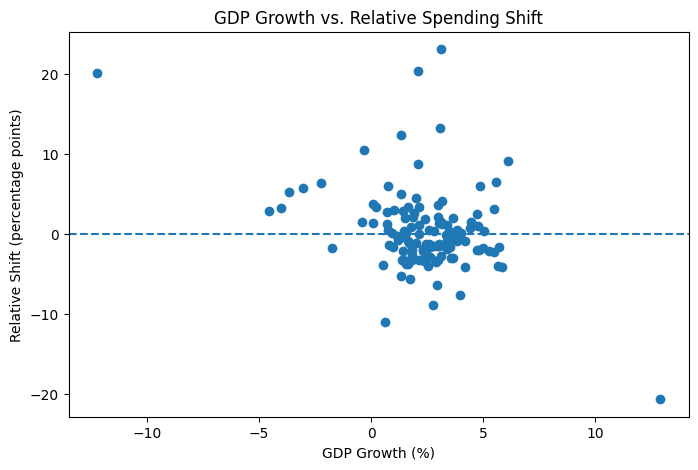

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    analysis_data["GDP Growth"],
    analysis_data["Relative Shift"]
)

plt.xlabel("GDP Growth (%)")
plt.ylabel("Relative Shift (percentage points)")
plt.title("GDP Growth vs. Relative Spending Shift")

plt.axhline(0, linestyle="--")

plt.show()

Across the full sample, GDP growth and Relative Shift have a moderate negative correlation (r ≈ −0.40), meaning that lower GDP growth tends to be associated with a higher Relative Shift. This is consistent with affordable indulgences performing relatively better than big-ticket goods when economic growth is weaker. However, extreme observations—particularly around the COVID-19 contraction and rebound—may influence this relationship.

In [16]:
import statsmodels.api as sm

# linear regression using Ordinary Least Squares (OLS)
X = analysis_data[ # X are the economic indicators / variables we will use to PREDICT relative shift
    [
        "Unemployment Rate",
        "Inflation",
        "GDP Growth",
        "Bank Rate"
    ]
]

y = analysis_data["Relative Shift"] # y is the variable we are trying to PREDICT 

X = sm.add_constant(X) # adds constant column to X

model = sm.OLS(y,X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Relative Shift   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.367
Method:                 Least Squares   F-statistic:                     19.67
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           1.41e-12
Time:                        12:12:22   Log-Likelihood:                -366.78
No. Observations:                 130   AIC:                             743.6
Df Residuals:                     125   BIC:                             757.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -3.3759      2.86

In [17]:
non_covid_data = analysis_data[ # performs regression on data EXCLUDING covid years to check whether or not the regression results are driven by the economic volatility of the COVID years 2020-2021
    ~analysis_data["Quarter"].between("2020Q1", "2021Q4")
].copy()

X_non_covid = non_covid_data[
    [
        "Unemployment Rate",
        "Inflation",
        "GDP Growth",
        "Bank Rate"
    ]
]

y_non_covid = non_covid_data["Relative Shift"]

X_non_covid = sm.add_constant(X_non_covid)

model_non_covid = sm.OLS(y_non_covid, X_non_covid).fit()

print(model_non_covid.summary())

                            OLS Regression Results                            
Dep. Variable:         Relative Shift   R-squared:                       0.260
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     10.26
Date:                Fri, 11 Sep 2026   Prob (F-statistic):           3.71e-07
Time:                        12:12:22   Log-Likelihood:                -335.32
No. Observations:                 122   AIC:                             680.6
Df Residuals:                     117   BIC:                             694.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -2.8245      2.95

So the macroeconomic variables explain about 38.6% of variation in Relative Shift in the full sample, compared with 26.0% outside our defined COVID window.

### ML Section: Can economic indicators actually predict the relative spending shift in future quarters?

In [18]:
# Define the macroeconomic features (predictors) that the ML models will use
features = [
    "Unemployment Rate",
    "Inflation",
    "GDP Growth",
    "Bank Rate"
]

# X contains the input features/economic indicators used to make predictions
X = analysis_data[features]

# y is the target/outcome we want the models to predict
y = analysis_data["Relative Shift"]


# Find the row position corresponding to 80% of the dataset
# This will be the boundary between the training and testing periods
split_index = int(len(analysis_data) * 0.8)


# Use the FIRST 80% of observations for training
# Because the data is chronologically ordered, these are the earlier quarters
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]


# Use the LAST 20% of observations for testing
# These are later quarters that the model does not see during training
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]



In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create a simple baseline model to give the ML models a benchmark to beat.
# The baseline always predicts the average Relative Shift from the TRAINING period.

# Calculate the average Relative Shift in the training data
baseline_prediction = y_train.mean()

# Predict that same training-period average for every observation in the test period
baseline_predictions = [baseline_prediction] * len(y_test)


# Calculate the Mean Absolute Error (MAE):
# the average absolute difference between the actual and predicted Relative Shift.
# Lower MAE = better predictions.
baseline_mae = mean_absolute_error(
    y_test,
    baseline_predictions
)


# Calculate Root Mean Squared Error (RMSE):
# measures prediction error but penalizes large mistakes more heavily than MAE.
# Lower RMSE = better predictions.
baseline_rmse = mean_squared_error(
    y_test,
    baseline_predictions
) ** 0.5


# Calculate R²:
# measures predictive performance relative to predicting the mean of the TEST data.
# Higher R² = better; R² can be negative for poor out-of-sample predictions.
baseline_r2 = r2_score(
    y_test,
    baseline_predictions
)


# Display the baseline performance metrics.
# Our ML models should ideally outperform this simple benchmark.
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)
print("Baseline R²:", baseline_r2)

Baseline MAE: 7.844773544540237
Baseline RMSE: 10.387392326267525
Baseline R²: -0.2902479388825552


In [20]:
from sklearn.linear_model import LinearRegression

# Create a Linear Regression model
linear_model = LinearRegression()

# Train the model using the earlier 80% of the data:
# X_train = historical economic indicators
# y_train = the Relative Shift that actually occurred during those quarters
# .fit() learns the linear relationship between the economic indicators and Relative Shift
linear_model.fit(X_train, y_train)


# Give the trained model the economic indicators from the unseen test period (X_test)
# and ask it to predict Relative Shift for each test quarter
linear_predictions = linear_model.predict(X_test)


# Compare the predicted Relative Shifts with the actual Relative Shifts (y_test)
# MAE = average absolute prediction error; lower is better
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)


# RMSE = prediction error that penalizes especially large mistakes more heavily;
# lower is better
linear_rmse = mean_squared_error(
    y_test,
    linear_predictions
) ** 0.5


# R² measures how well the model predicts variation in Relative Shift
# in the unseen test data; higher is better and it can be negative
linear_r2 = r2_score(
    y_test,
    linear_predictions
)


# Display the Linear Regression's out-of-sample performance
# so it can be compared with the baseline and Random Forest
print("Linear Regression MAE:", linear_mae)
print("Linear Regression RMSE:", linear_rmse)
print("Linear Regression R²:", linear_r2)

Linear Regression MAE: 7.212081693558615
Linear Regression RMSE: 9.40563895865305
Linear Regression R²: -0.05788074427241763


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=500, # no. of decision trees
    random_state=42 # makes randomness reproducible
)

rf_model.fit(X_train, y_train) # train the random forest using training data

rf_predictions = rf_model.predict(X_test)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)
print("Random Forest RMSE:", rf_rmse)
print("Random Forest R²:", rf_r2)

feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)
# How much did each feature contribute to reducing prediction error/impurity across your trees?

feature_importance

Random Forest MAE: 6.218340901761836
Random Forest RMSE: 8.223066176027418
Random Forest R²: 0.19141128735002788


,Feature,Importance
0,Unemployment Rate,0.367107
2,GDP Growth,0.325024
3,Bank Rate,0.156253
1,Inflation,0.151616


Unemployment showed little evidence of an independent linear association in OLS, but it was the most important feature in the Random Forest's predictions, suggesting it may contain predictive information that is nonlinear.

In [22]:
from sklearn.inspection import permutation_importance

# permutation importance measures how much worse a trained model performs when we randomly scramble one feature. The more performance deteriorates, the more important that feature was to the model's predictions. 
perm_importance = permutation_importance(
    rf_model,       # Use the Random Forest that has already been trained

    X_test,         # Scramble features in the unseen test data

    y_test,         # Actual Relative Shift values used to evaluate performance

    n_repeats=30,   # Scramble each feature 30 times and average the results
    # to reduce the effect of random chance

    random_state=42,  # Makes the random scrambling reproducible

    scoring="neg_mean_absolute_error"
    # Evaluate how scrambling each feature affects MAE.
    # sklearn uses negative MAE because its scoring system treats higher scores as better.
)
perm_df = pd.DataFrame({
    "Feature": features,
    "Permutation Importance": perm_importance.importances_mean
})

perm_df = perm_df.sort_values(
    "Permutation Importance",
    ascending=False
)

perm_df

,Feature,Permutation Importance
0,Unemployment Rate,1.005057
2,GDP Growth,0.558530
3,Bank Rate,0.226492
1,Inflation,0.082454


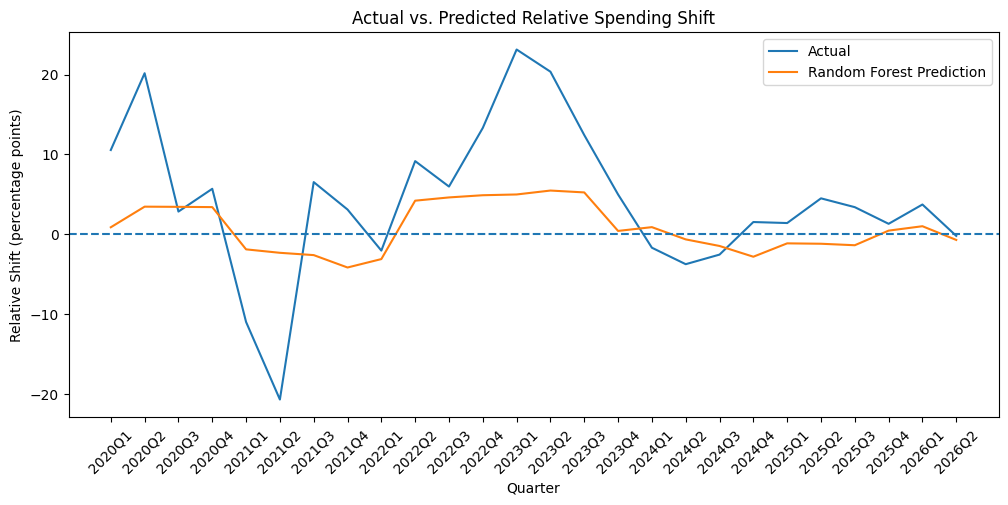

In [23]:
prediction_results = pd.DataFrame({
    "Quarter": analysis_data["Quarter"].iloc[split_index:].astype(str),
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

prediction_results.head()

# plots random forest predicted shift against actual relative shift
plt.figure(figsize=(12, 5))

plt.plot(
    prediction_results["Quarter"],
    prediction_results["Actual"],
    label="Actual"
)

plt.plot(
    prediction_results["Quarter"],
    prediction_results["Predicted"],
    label="Random Forest Prediction"
)

plt.axhline(0, linestyle="--")

plt.title("Actual vs. Predicted Relative Spending Shift")
plt.xlabel("Quarter")
plt.ylabel("Relative Shift (percentage points)")

plt.xticks(rotation=45)
plt.legend()

plt.show()

In [24]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5) # create five different train/test experiments while preserving chronological order

for fold, (train_index, test_index) in enumerate(tscv.split(X), start=1):

    print(f"Fold {fold}")

    print(
        "Training:",
        analysis_data["Quarter"].iloc[train_index[0]],
        "to",
        analysis_data["Quarter"].iloc[train_index[-1]]
    )

    print(
        "Testing:",
        analysis_data["Quarter"].iloc[test_index[0]],
        "to",
        analysis_data["Quarter"].iloc[test_index[-1]]
    )

    print()



Fold 1
Training: 1994Q1 to 2000Q1
Testing: 2000Q2 to 2005Q2

Fold 2
Training: 1994Q1 to 2005Q2
Testing: 2005Q3 to 2010Q3

Fold 3
Training: 1994Q1 to 2010Q3
Testing: 2010Q4 to 2015Q4

Fold 4
Training: 1994Q1 to 2015Q4
Testing: 2016Q1 to 2021Q1

Fold 5
Training: 1994Q1 to 2021Q1
Testing: 2021Q2 to 2026Q2



In [25]:
# Create empty lists to store the MAE from each cross-validation fold
# for Linear Regression and Random Forest
linear_maes = []
rf_maes = []


# Loop through each chronological train/test split created by TimeSeriesSplit.
# train_index and test_index contain the row positions assigned to training and testing.
for train_index, test_index in tscv.split(X):

    # Use the row indices for this fold to create the training and testing datasets.
    # Earlier observations are used for training and later observations for testing.
    X_train_cv = X.iloc[train_index]
    X_test_cv = X.iloc[test_index]

    y_train_cv = y.iloc[train_index]
    y_test_cv = y.iloc[test_index]


    # ----- LINEAR REGRESSION -----

    # Create a new Linear Regression model for this fold
    linear_cv = LinearRegression()

    # Train it using only this fold's training data
    linear_cv.fit(X_train_cv, y_train_cv)

    # Predict Relative Shift for this fold's unseen test period
    linear_pred_cv = linear_cv.predict(X_test_cv)

    # Calculate the Linear Regression's MAE for this test period
    linear_mae_cv = mean_absolute_error(
        y_test_cv,
        linear_pred_cv
    )

    # Save this fold's MAE so we can compare performance across all folds
    linear_maes.append(linear_mae_cv)


    # ----- RANDOM FOREST -----

    # Create a new Random Forest model for this fold
    rf_cv = RandomForestRegressor(
        n_estimators=500,
        random_state=42
    )

    # Train it using this fold's training data
    rf_cv.fit(X_train_cv, y_train_cv)

    # Predict Relative Shift for this fold's unseen test period
    rf_pred_cv = rf_cv.predict(X_test_cv)

    # Calculate the Random Forest's MAE for this test period
    rf_mae_cv = mean_absolute_error(
        y_test_cv,
        rf_pred_cv
    )

    # Save this fold's MAE
    rf_maes.append(rf_mae_cv)


# Display the MAE from every fold for both models
print("Linear Regression fold MAEs:", linear_maes)
print("Random Forest fold MAEs:", rf_maes)

# Calculate the average MAE across all 5 time periods
# to compare the models' overall out-of-sample performance
print("\nAverage Linear Regression MAE:", np.mean(linear_maes))
print("Average Random Forest MAE:", np.mean(rf_maes))

Linear Regression fold MAEs: [1.8428256741429268, 2.0254340422844974, 2.264626073411669, 3.6798189618271784, 7.208294737787717]
Random Forest fold MAEs: [1.8988013078213068, 2.449239452868698, 2.3395149297535305, 4.217018714269211, 5.904278826483035]

Average Linear Regression MAE: 3.4041998978907975
Average Random Forest MAE: 3.361770646239157


In [26]:
model_results = pd.DataFrame({ # creates a data frame comparing the 3 models performance
    "Model": [
        "Baseline",
        "Linear Regression",
        "Random Forest"
    ],

    "Test MAE": [
        baseline_mae,
        linear_mae,
        rf_mae
    ],

    "Test RMSE": [
        baseline_rmse,
        linear_rmse,
        rf_rmse
    ],

    "Test R²": [
        baseline_r2,
        linear_r2,
        rf_r2
    ]
})

model_results

,Model,Test MAE,Test RMSE,Test R²
0,Baseline,7.844774,10.387392,-0.290248
1,Linear Regression,7.212082,9.405639,-0.057881
2,Random Forest,6.218341,8.223066,0.191411


In [27]:
cv_results = pd.DataFrame({ # compares the performance across the time-series cross validated folds
    "Fold": [1, 2, 3, 4, 5],

    "Linear Regression MAE": linear_maes,

    "Random Forest MAE": rf_maes
})

cv_results

print(
    "Average Linear Regression MAE:",
    np.mean(linear_maes)
)

print(
    "Average Random Forest MAE:",
    np.mean(rf_maes)
)

Average Linear Regression MAE: 3.4041998978907975
Average Random Forest MAE: 3.361770646239157
